# OncoLab AI — Data Preparation Notebook
## From raw clinical data to the longitudinal dataset

**Author and ML Engineer:** Zeroual Dhia Eddine · Final-Year Project in Pharmacy
**Clinical supervisor:** Nadia Kerraouch

This notebook transforms the clinical team's raw CSV into a longitudinal dataset ready for machine learning.
Each step is documented to be transparent and reproducible.

# OncoLab AI — Notebook de Préparation des Données
## Des données cliniques brutes au jeu de données longitudinal

**Auteur et ML Engineer :** Zeroual Dhia Eddine · Projet de Fin d'Études en Pharmacie
**Encadrant clinique :** Nadia Kerraouch

Ce notebook transforme le CSV brut de l'équipe clinique en un jeu de données longitudinal prêt pour l'apprentissage automatique.
Chaque étape est documentée pour être transparente et reproductible.


---
## 1. Loading the Raw Data

## 1. Chargement des données brutes


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
ROOT = Path('..') if Path('../data').exists() else Path('.')
RAW_PATH = ROOT / 'data' / 'raw' / 'Collect Data Onco Lab AI - Feuille 2.csv'
OUT_PATH = ROOT / 'data' / 'dataset_longitudinal.csv'

raw = pd.read_csv(RAW_PATH)
raw.columns = [c.strip() for c in raw.columns]

print(f'Raw shape    : {raw.shape}')
print(f'Patient IDs  : {raw["Patient ID"].nunique()} unique strings')
print(f'Columns ({len(raw.columns)}):')
for c in raw.columns: print(f'  {c}')

Raw shape    : (947, 42)
Patient IDs  : 110 unique strings
Columns (42):
  Patient ID
  Age
  Sexe
  IMC
  Etat
  HTA
  Diabéte
  Maladies rénales
  Maladies hépatiques
  Type
  Stade
  Métastase
  Cure
  Intervalle
  Dose de l'oxali
  Dose de 5-FUb
  Dose de 5-FUc
  Dose de AF
  Adj/Neoadj
  Hb
  Neut
  Plq
  Urée
  Creat
  ASAT
  ALAT
  Bil
  Anémie
  Sévérité
  Neutropénie
  Sévérité.1
  Thrombopénie
  Sévérité.2
  Toxicité rénale
  Sévérité.3
  Toxicité hépatique
  Sévérité.4
  Autres toxicités
  Réduction de la dose
  Report de la cure
  changement du protocole
  Remarques


In [2]:
raw.head(3)

,Patient ID,Age,Sexe,IMC,Etat,HTA,Diabéte,Maladies rénales,Maladies hépatiques,Type,...,Sévérité.2,Toxicité rénale,Sévérité.3,Toxicité hépatique,Sévérité.4,Autres toxicités,Réduction de la dose,Report de la cure,changement du protocole,Remarques
0,P1,50,H,"25,1",surpoid,1,1,0,0,Colon,...,0,0,0,0,0,0,0.0,0.0,0.0,NaN
1,P1,50,H,"25,1",surpoid,1,1,0,0,Colon,...,0,0,0,0,0,Vomissement,0.0,0.0,0.0,NaN
2,P1,50,H,"25,1",surpoid,1,1,0,0,Colon,...,0,0,0,0,0,0,0.0,0.0,0.0,NaN


---
## 2. Renaming and Encoding

The raw CSV has column names in French and numbers in European format (comma as the decimal separator).
We rename all columns to English snake_case and convert the numbers.

## 2. Renommage et encodage

Le CSV brut a des noms de colonnes en français et des nombres au format européen (séparateur décimal virgule).
On renomme toutes les colonnes en snake_case anglais et on convertit les nombres.


In [3]:
COLUMN_RENAME = {
    'Patient ID':'patient_id', 'Age':'age', 'Sexe':'sex_raw', 'IMC':'bmi', 'Etat':'etat',
    'HTA':'hta', 'Diabéte':'diabetes',
    'Maladies rénales':'renal_disease', 'Maladies hépatiques':'hepatic_disease',
    'Type':'cancer_type', 'Stade':'tnm', 'Métastase':'metastasis_site',
    'Cure':'cure_raw', 'Intervalle':'interval_raw',
    "Dose de l'oxali":'dose_oxali', 'Dose de 5-FUb':'dose_5fu_bolus',
    'Dose de 5-FUc':'dose_5fu_cont', 'Dose de AF':'dose_af',
    'Adj/Neoadj':'treatment_intent',
    'Hb':'hb', 'Neut':'neut', 'Plq':'plq', 'Urée':'uree',
    'Creat':'creat', 'ASAT':'asat', 'ALAT':'alat', 'Bil':'bil',
    'Anémie':'anemia', 'Sévérité':'sev_anemia',
    'Neutropénie':'neutropenia', 'Sévérité.1':'sev_neutropenia',
    'Thrombopénie':'thrombocytopenia', 'Sévérité.2':'sev_thrombocytopenia',
    'Toxicité rénale':'renal_toxicity', 'Sévérité.3':'sev_renal',
    'Toxicité hépatique':'hepatic_toxicity', 'Sévérité.4':'sev_hepatic',
}

df = raw.rename(columns=COLUMN_RENAME).copy()

# EU decimal parsing
def parse_eu_float(x):
    if pd.isna(x): return pd.NA
    s = str(x).strip().replace(',', '.')
    if s == '' or s.lower() == 'nan': return pd.NA
    try: return float(s)
    except ValueError: return pd.NA

def parse_int_or_na(x):
    if pd.isna(x): return pd.NA
    s = str(x).strip()
    if s == '' or s.lower() == 'nan': return pd.NA
    try: return int(float(s.replace(',', '.')))
    except ValueError: return pd.NA

EU_FLOAT_COLS = ['bmi','hb','neut','plq','uree','creat','asat','alat','bil',
                 'dose_oxali','dose_5fu_bolus','dose_5fu_cont','dose_af']
BINARY_COLS = ['hta','diabetes','renal_disease','hepatic_disease',
               'anemia','neutropenia','thrombocytopenia','renal_toxicity','hepatic_toxicity']

for c in EU_FLOAT_COLS:
    df[c] = df[c].apply(parse_eu_float).astype('Float64')
for c in BINARY_COLS + ['age']:
    df[c] = df[c].apply(parse_int_or_na).astype('Int64')

# Sex encoding
df['sex_M'] = (df['sex_raw'].astype(str).str.strip().str.upper() == 'H').astype('Int64')

# Comorbidity count
df['comorbidity_count'] = df[['hta','diabetes','renal_disease','hepatic_disease']].sum(axis=1)

print('After rename/encode:', df.shape)
print('hb (first 5):', df['hb'].head(5).tolist())
print('sex_M counts:', df['sex_M'].value_counts().to_dict())

After rename/encode: (947, 44)
hb (first 5): [11.7, 11.6, 11.2, 11.4, 11.6]
sex_M counts: {np.int64(1): 673, np.int64(0): 274}


---
## 3. Parsing Structured Strings

Several fields encode multiple values in a single string. We break them down into separate numeric columns:
- `Cure` (e.g. `"C3"`) → integer `cycle_num`
- `Intervalle` (e.g. `"15J"`) → integer `interval_days`
- `Stade` (e.g. `"T3N1M0"`) → integers `T_stage`, `N_stage`, `M_stage`

## 3. Analyse des chaînes structurées

Plusieurs champs encodent des valeurs multiples dans une seule chaîne. On les décompose en colonnes numériques séparées :
- `Cure` (ex. `"C3"`) → entier `cycle_num`
- `Intervalle` (ex. `"15J"`) → entier `interval_days`
- `Stade` (ex. `"T3N1M0"`) → entiers `T_stage`, `N_stage`, `M_stage`


In [4]:
# Cycle number
df['cycle_num'] = (
    df['cure_raw'].astype(str).str.strip().str.upper()
    .str.extract(r'C(\d+)', expand=False)
    .apply(parse_int_or_na).astype('Int64')
)

# Interval in days
df['interval_days'] = (
    df['interval_raw'].astype(str).str.extract(r'(\d+)', expand=False)
    .apply(parse_int_or_na).astype('Int64')
)

# TNM staging
tnm = df['tnm'].astype(str).str.upper()
df['T_stage'] = tnm.str.extract(r'T(\d)', expand=False).apply(parse_int_or_na).astype('Int64')
df['N_stage'] = tnm.str.extract(r'N(\d)', expand=False).apply(parse_int_or_na).astype('Int64')
df['M_stage'] = tnm.str.extract(r'M(\d)', expand=False).apply(parse_int_or_na).astype('Int64')

# Metastasis flag from the Métastase column ('0' or 'foie', 'foie+poumon', ...)
df['has_metastasis'] = (
    df['metastasis_site'].astype(str).str.strip().str.lower()
    .replace({'nan':'0', '':'0'}) != '0'
).astype('Int64')

print('cycle_num range :', df['cycle_num'].min(), '→', df['cycle_num'].max())
print('interval_days   :', df['interval_days'].unique())
print('T_stage values  :', sorted(df['T_stage'].dropna().unique().tolist()))

cycle_num range : 0 → 17
interval_days   : <IntegerArray>
[15, 21]
Length: 2, dtype: Int64
T_stage values  : [1, 2, 3, 4]


---
## 4. Normalizing Categorical Variables

The free-text fields have inconsistencies in capitalization and spelling that must be normalized
before encoding or modeling.

## 4. Normalisation des catégorielles

Les champs en texte libre ont des incohérences de casse et d'orthographe qui doivent être normalisées
avant l'encodage ou la modélisation.


In [5]:
ETAT_MAP = {
    'sous-poids':'Sous-poids', 'sous poids':'Sous-poids', 'souspoids':'Sous-poids',
    'normale':'Normale', 'normal':'Normale',
    'surpoid':'Surpoids', 'surpoids':'Surpoids',
}
df['etat'] = (
    df['etat'].astype(str).str.strip().str.lower()
    .map(ETAT_MAP).fillna(df['etat'])
)

df['treatment_intent'] = (
    df['treatment_intent'].astype(str).str.strip().str.lower()
    .map({'adj':'Adj', 'neoadj':'Neoadj'}).fillna(df['treatment_intent'])
)

df['cancer_type'] = (
    df['cancer_type'].astype(str).str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
df['cancer_type'] = df['cancer_type'].apply(
    lambda s: s[:1].upper() + s[1:].lower() if isinstance(s, str) and s else s
)

print('etat            :', df['etat'].unique())
print('treatment_intent:', df['treatment_intent'].unique())
print('cancer_type     :', df['cancer_type'].unique())

etat            : ['Surpoids' 'Sous-poids' 'Normale' 'obésité modéré']
treatment_intent: ['Neoadj' 'Adj']
cancer_type     : ['Colon' 'Colon sigmoide' 'Moyen rectum' 'Colon droit' 'Bas rectum'
 'Colon gauche' 'Colon sigmoid' 'Moyen et haut rectum' 'Haut rectum'
 'Colon+péritoine' 'Rectum' 'Colon+rectum' 'Colon droite']


---
## 5. Normalizing the Patient Identifier

The raw data contains a lowercase patient identifier `p16` for a single patient who should be
`P16`. We convert all identifiers to uppercase to fix the mismatch.

## 5. Normalisation de l'identifiant patient

Les données brutes contiennent un identifiant patient en minuscules `p16` pour un seul patient qui devrait
être `P16`. On met tous les identifiants en majuscules pour résoudre la correspondance.


In [6]:
before = df['patient_id'].nunique()
df['patient_id'] = df['patient_id'].astype(str).str.upper().str.strip()
after = df['patient_id'].nunique()
print(f'Unique patient IDs: {before} → {after}  (merged: {before - after})')

Unique patient IDs: 110 → 109  (merged: 1)


---
## 6. Correcting Data Entry Errors

Two specific problems were identified during the EDA and require correction:

1. **Patient P31** — The TNM string is corrupted in the raw file. Based on the clinical context, the correct stage is `T3N1M0`.
2. **Patient P107** — The stage label is `"Stade 4"` with no M digit. Stage IV implies metastatic disease, so we set `M_stage = 1`.
3. **Value `uree = 36`** in 1 row — clearly a decimal point error (should be 0.36 g/L). Divided by 100.

## 6. Correction des erreurs de saisie

Deux problèmes spécifiques ont été identifiés lors de l'AED et nécessitent une correction :

1. **Patient P31** — La chaîne TNM est corrompue dans le fichier brut. D'après le contexte clinique, le stade correct est `T3N1M0`.
2. **Patient P107** — Le libellé de stade est `"Stade 4"` sans chiffre M. Le stade IV implique une maladie métastatique, donc on définit `M_stage = 1`.
3. **Valeur `uree = 36`** dans 1 ligne — clairement une erreur de virgule décimale (devrait être 0,36 g/L). Division par 100.


In [7]:
# P31: TNM corruption
df.loc[df['patient_id']=='P31', 'tnm'] = 'T3N1M0'

# Re-extract T, N, M after the fix
tnm = df['tnm'].astype(str).str.upper()
df['T_stage'] = tnm.str.extract(r'T(\d)', expand=False).apply(parse_int_or_na).astype('Int64')
df['N_stage'] = tnm.str.extract(r'N(\d)', expand=False).apply(parse_int_or_na).astype('Int64')
df['M_stage'] = tnm.str.extract(r'M(\d)', expand=False).apply(parse_int_or_na).astype('Int64')

# Stade 4 → M_stage = 1
stade4_mask = tnm.str.contains(r'STADE\s*4', regex=True)
df.loc[stade4_mask, 'M_stage'] = 1

print('NaN in T_stage after fix:', df['T_stage'].isna().sum())
print('Stade 4 rows fixed       :', stade4_mask.sum())

NaN in T_stage after fix: 4
Stade 4 rows fixed       : 4


---
## 7. Deduplication

**Problem:** 20 patients have repeated rows for the same cycle, with slightly different biomarker values.
This corresponds to rescheduled cycles — the first row is the postponed cycle, the last one is the cycle actually administered.

**Resolution:** sort by `(patient_id, cycle_num)`, keep the last row of each duplicate.

## 7. Dédoublonnage

**Problème :** 20 patients ont des lignes répétées pour la même cure, avec des valeurs de biomarqueurs légèrement différentes.
Cela correspond à des cures reprogrammées — la première ligne est la cure reportée, la dernière est celle administrée.

**Résolution :** trier par `(patient_id, cycle_num)`, conserver la dernière ligne de chaque doublon.


In [8]:
# Sort with stable ordering to preserve original CSV order within ties
df = df.sort_values(['patient_id','cycle_num'], kind='stable').reset_index(drop=True)

before = len(df)
dup_mask = df.duplicated(subset=['patient_id','cycle_num'], keep=False)
dup_patients = sorted(df.loc[dup_mask, 'patient_id'].unique())
df = df.drop_duplicates(['patient_id','cycle_num'], keep='last').reset_index(drop=True)

# Defensive: drop rows where cycle_num is somehow NaN
df = df.dropna(subset=['cycle_num']).reset_index(drop=True)

print(f'Removed {before - len(df)} duplicate rows.')
print(f'Affected patients ({len(dup_patients)}): {dup_patients}')
print(f'Rows after dedup: {len(df)}')
print(f'data shape after dedup: {df.shape}')

Removed 26 duplicate rows.
Affected patients (20): ['P103', 'P104', 'P105', 'P106', 'P107', 'P108', 'P13', 'P20', 'P22', 'P26', 'P27', 'P30', 'P31', 'P34', 'P35', 'P39', 'P42', 'P52', 'P60', 'P7']
Rows after dedup: 921
data shape after dedup: (921, 50)


---
## 8. Feature Engineering

All features are computed **within each patient's chronological history** using
`groupby('patient_id')` after sorting by `cycle_num`. Using values from future cycles would be data leakage.

### Feature families:
| Family | Columns | Clinical meaning |
|---|---|---|
| Lagged biomarkers (t-1, t-2) | `hb_t1`, `neut_t1`, `plq_t1`, `creat_t1`, and `_t2` | Where the patient stood 1 or 2 cycles earlier |
| Previous complications | `anemia_t1`, …, `hepatic_toxicity_t2` | Recurrence signal |
| Delta | `delta_hb`, `delta_neut`, `delta_plq` | Speed and direction of change |
| Trend | `trend_neut_3cycles` | Average level over 3 cycles |
| Variability | `variability_neut` | Volatility over 3 cycles |
| Drop rate | `drop_rate_plq` | Relative decline over 2 cycles |

## 8. Ingénierie des variables

Toutes les variables sont calculées **au sein de l'historique chronologique de chaque patient** en utilisant
`groupby('patient_id')` après tri par `cycle_num`. L'utilisation de valeurs provenant de cycles futurs serait une fuite de données.

### Familles de variables :
| Famille | Colonnes | Signification clinique |
|---|---|---|
| Biomarqueurs décalés (t-1, t-2) | `hb_t1`, `neut_t1`, `plq_t1`, `creat_t1`, et `_t2` | Où en était le patient 1 ou 2 cycles auparavant |
| Complications antérieures | `anemia_t1`, …, `hepatic_toxicity_t2` | Signal de récurrence |
| Delta | `delta_hb`, `delta_neut`, `delta_plq` | Vitesse et direction du changement |
| Tendance | `trend_neut_3cycles` | Niveau moyen sur 3 cycles |
| Variabilité | `variability_neut` | Volatilité sur 3 cycles |
| Taux de chute | `drop_rate_plq` | Déclin relatif sur 2 cycles |


In [9]:
LAG_BIO = ['hb', 'neut', 'plq', 'creat']
COMPLICATIONS = ['anemia', 'neutropenia', 'thrombocytopenia', 'renal_toxicity', 'hepatic_toxicity']

# Sort chronologically within each patient — all window ops depend on this
df = df.sort_values(['patient_id','cycle_num'], kind='stable').reset_index(drop=True)
g = df.groupby('patient_id', group_keys=False)

# Lagged bio markers
for col in LAG_BIO:
    df[f'{col}_t1'] = g[col].shift(1)
    df[f'{col}_t2'] = g[col].shift(2)

# Lagged complications
for c in COMPLICATIONS:
    df[f'{c}_t1'] = g[c].shift(1)
    df[f'{c}_t2'] = g[c].shift(2)

# Derived features
df['delta_hb']   = df['hb']   - df['hb_t1']
df['delta_neut'] = df['neut'] - df['neut_t1']
df['delta_plq']  = df['plq']  - df['plq_t1']

df['trend_neut_3cycles'] = df[['neut_t2','neut_t1','neut']].mean(axis=1)
df['variability_neut']   = df[['neut_t2','neut_t1','neut']].std(axis=1)
df['drop_rate_plq']      = (df['plq'] - df['plq_t2']) / df['plq_t2']

# Rename complication columns to targets (no shift — same row)
df = df.rename(columns={c: f'target_{c}' for c in COMPLICATIONS})

print('After feature engineering:', df.shape)



After feature engineering: (921, 74)


In [10]:
# Spot-check formulas on patient P1
p1 = df[df['patient_id']=='P1'][[
    'cycle_num','neut','neut_t1','neut_t2','delta_neut',
    'trend_neut_3cycles','variability_neut','plq','plq_t2','drop_rate_plq',
    'anemia_t1','target_anemia']].head(5)
print(p1.to_string())

   cycle_num    neut  neut_t1  neut_t2  delta_neut  trend_neut_3cycles  variability_neut       plq    plq_t2  drop_rate_plq  anemia_t1  target_anemia
0          0  9013.0     <NA>     <NA>        <NA>              9013.0              <NA>  374000.0      <NA>           <NA>       <NA>              1
1          1  8390.0   9013.0     <NA>      -623.0              8701.5        440.527525  351000.0      <NA>           <NA>          1              1
2          2  3270.0   8390.0   9013.0     -5120.0              6891.0       3151.311314  288000.0  374000.0      -0.229947          1              1
3          3  3170.0   3270.0   8390.0      -100.0         4943.333333       2985.319637  152000.0  351000.0      -0.566952          1              1
4          4  2820.0   3170.0   3270.0      -350.0         3086.666667        236.290781  143000.0  288000.0      -0.503472          1              1


---
## 9. Filtering — Removing Rows Without History

The first two cycles of each patient do not have a 2-cycle history (the `_t2` features are NaN).
These rows are removed because the longitudinal model requires at least 2 cycles of history.

## 9. Filtrage — suppression des lignes sans historique

Les deux premières cures de chaque patient n'ont pas d'historique de 2 cycles (les variables `_t2` sont NaN).
Ces lignes sont supprimées car le modèle longitudinal nécessite au minimum 2 cycles d'historique.


In [11]:
STATIC = ['patient_id','age','sex_M','bmi','etat',
          'hta','diabetes','renal_disease','hepatic_disease','comorbidity_count',
          'cancer_type','T_stage','N_stage','M_stage','has_metastasis',
          'treatment_intent']
CYCLE  = ['cycle_num','interval_days']
DOSE   = ['dose_oxali','dose_5fu_bolus','dose_5fu_cont','dose_af']
BIO    = ['hb','neut','plq','uree','creat','asat','alat','bil']

LAG_T1 = [f'{c}_t1' for c in LAG_BIO]
LAG_T2 = [f'{c}_t2' for c in LAG_BIO]
COMP_T1 = [f'{c}_t1' for c in COMPLICATIONS]
COMP_T2 = [f'{c}_t2' for c in COMPLICATIONS]
DERIVED = ['delta_hb','delta_neut','delta_plq',
           'trend_neut_3cycles','drop_rate_plq','variability_neut']
TARGETS = [f'target_{c}' for c in COMPLICATIONS]
FINAL_COLS = STATIC + CYCLE + DOSE + BIO + LAG_T1 + LAG_T2 + COMP_T1 + COMP_T2 + DERIVED + TARGETS

# Drop rows where any t-2 lag is NaN (first 2 cycles per patient)
required = [f'{c}_t2' for c in LAG_BIO]
df_long = df.dropna(subset=required).reset_index(drop=True)
df_long = df_long[FINAL_COLS]

print(f'Final shape : {df_long.shape}')
print(f'Patients    : {df_long["patient_id"].nunique()}')
missing = df_long.isna().sum()
missing = missing[missing > 0]
print()
print('Remaining missing values:')
print(missing.to_string() if len(missing) else 'None')

Final shape : (704, 59)
Patients    : 108

Remaining missing values:
T_stage    1
N_stage    1


---
## 10. Validation

## 10. Validation


In [12]:
# Shape sanity checks
n_rows, n_cols = df_long.shape
assert n_cols == 59, f'Expected 59 columns, got {n_cols}'
assert 700 <= n_rows <= 730, f'Row count {n_rows} outside expected range'
print(f'Shape   : ({n_rows}, {n_cols})   PASSED')

# Feature spot-check: P1 cycle 2
p1c2 = df_long[(df_long['patient_id']=='P1') & (df_long['cycle_num']==2)].iloc[0]
assert abs(p1c2['trend_neut_3cycles'] - 6891.0)   < 0.1
assert abs(p1c2['variability_neut']   - 3151.31)  < 0.1
assert abs(p1c2['drop_rate_plq']      - (-0.2299)) < 0.001
assert abs(p1c2['delta_hb'] - (-0.4)) < 0.001
assert p1c2['anemia_t1'] == 1.0
print('Features: PASSED  (trend, variability, drop_rate, delta, prior flag)')

# Class imbalance
rates = df_long[TARGETS].mean().sort_values(ascending=False)
rates.index = rates.index.str.replace('target_', '', regex=False)
print()
print('Complication prevalence:')
print(rates.apply(lambda x: f'{x:.1%}').to_string())

Shape   : (704, 59)   PASSED
Features: PASSED  (trend, variability, drop_rate, delta, prior flag)

Complication prevalence:
anemia              68.0%
hepatic_toxicity    28.6%
thrombocytopenia    17.9%
renal_toxicity       9.1%
neutropenia          5.1%


---
## 11. Complication Prevalence

## 11. Prévalence des complications


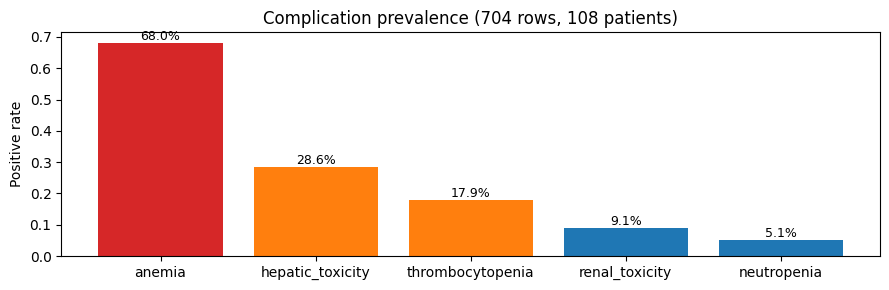

In [13]:
fig, ax = plt.subplots(figsize=(9, 3))
colors = ['#d62728' if r > 0.3 else '#ff7f0e' if r > 0.1 else '#1f77b4' for r in rates]
ax.bar(rates.index, rates.values, color=colors)
ax.set_ylabel('Positive rate')
ax.set_title(f'Complication prevalence ({len(df_long)} rows, {df_long["patient_id"].nunique()} patients)')
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 12. Export

`dataset_longitudinal.csv` is the direct input of the `model_longitudinal.ipynb` notebook.

## 12. Export

`dataset_longitudinal.csv` est l'entrée directe du notebook `model_longitudinal.ipynb`.


In [14]:
df_long.to_csv(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}')
print(f'Shape  : {df_long.shape}')
print(f'Columns: {list(df_long.columns)}')

Saved → ../data/dataset_longitudinal.csv
Shape  : (704, 59)
Columns: ['patient_id', 'age', 'sex_M', 'bmi', 'etat', 'hta', 'diabetes', 'renal_disease', 'hepatic_disease', 'comorbidity_count', 'cancer_type', 'T_stage', 'N_stage', 'M_stage', 'has_metastasis', 'treatment_intent', 'cycle_num', 'interval_days', 'dose_oxali', 'dose_5fu_bolus', 'dose_5fu_cont', 'dose_af', 'hb', 'neut', 'plq', 'uree', 'creat', 'asat', 'alat', 'bil', 'hb_t1', 'neut_t1', 'plq_t1', 'creat_t1', 'hb_t2', 'neut_t2', 'plq_t2', 'creat_t2', 'anemia_t1', 'neutropenia_t1', 'thrombocytopenia_t1', 'renal_toxicity_t1', 'hepatic_toxicity_t1', 'anemia_t2', 'neutropenia_t2', 'thrombocytopenia_t2', 'renal_toxicity_t2', 'hepatic_toxicity_t2', 'delta_hb', 'delta_neut', 'delta_plq', 'trend_neut_3cycles', 'drop_rate_plq', 'variability_neut', 'target_anemia', 'target_neutropenia', 'target_thrombocytopenia', 'target_renal_toxicity', 'target_hepatic_toxicity']
